# Análisis y visualización de datos con Python
# 11. Ciencia de datos

    - a) Conjunto de datos
    - b) Correlaciones
    - c) Pruebas de hipótesis múltiple
    - d) PCA (Análisis de Componentes Principales)
    - e) Selección de variables
    - f) Regresión logística
    - g) Resumen

---

En este tutorial utilizaremos las bibliotecas `sklearn` y `scipy`

In [1]:
#! pip install scikit-learn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import sqrt


from sklearn.datasets import load_breast_cancer

## 11.a Conjunto de datos

El dataset `breast_cancer` de `scikit-learn` es un conjunto de datos de cáncer de mama, que contiene información clínica y características de células de tumor para 569 pacientes. El objetivo del conjunto de datos es predecir si un tumor es benigno o maligno en función de estas características.

Las características de las células del tumor se calculan a partir de imágenes digitales de muestras de tejido de tumor de mama. En total, hay 30 características diferentes, que incluyen el radio, la textura, la simetría, la concavidad y otras medidas de la forma y el tamaño de las células del tumor. Para cada paciente, se proporciona un identificador único, la etiqueta de clase (benigno o maligno) y los valores de las 30 características.

Veamos la descripción del dataset.

In [2]:
cancer = load_breast_cancer()
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Ahora convertiremos los datos en un dataframe.

**Nota** En este conjunto de datos: 0:'maligno', 1:'benigno'

In [3]:
df_cancer = pd.DataFrame(data=cancer['data'], columns=cancer['feature_names'])
df_cancer['diagnostic'] = cancer['target']
df_cancer

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostic
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


Exploremos rápidamente los datos

In [4]:
df_cancer.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostic
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


Grafiquemos la distribución de los datos.

En este caso vamos a definir una función especial para graficar facilmente estos datos.

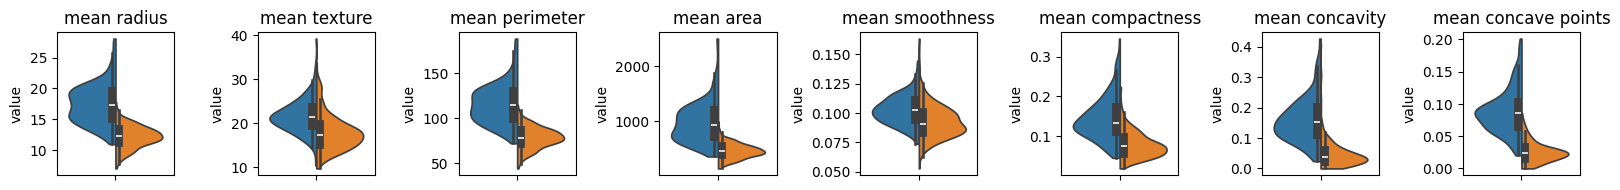

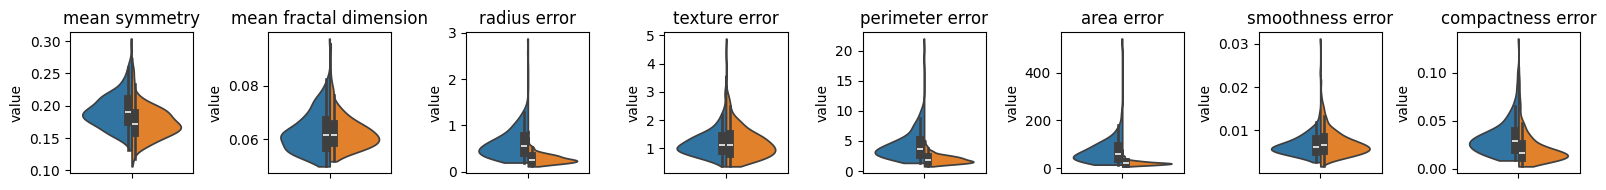

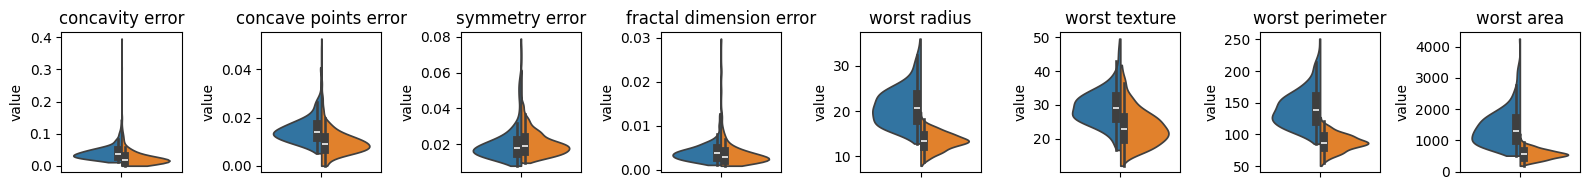

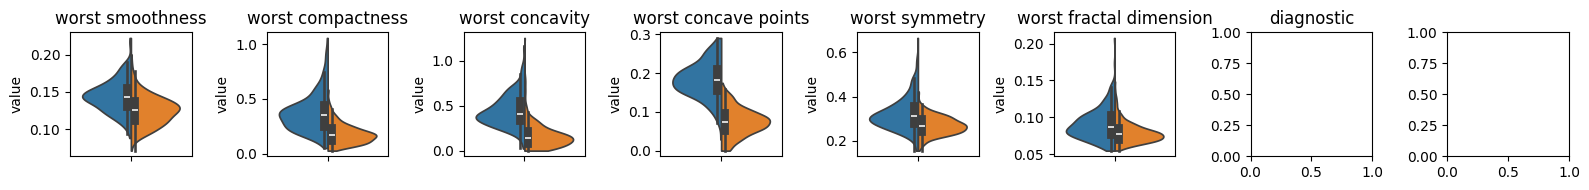

In [5]:
from math import ceil

def violin_plot_cancer(df, cols=None, n_row=8):
    # preparar datos
    if cols!=None:
        cols = cols+['diagnostic']
        data = df[cols]
    else:
        cols = df.columns
        data = df
    data = pd.melt(data, id_vars='diagnostic')
    # generar subgráficas
    chunks = [cols[i:i + n_row] for i in range(0, len(cols), n_row)]
    for chunk in chunks:
        fig, axs = plt.subplots(1,n_row)
        fig.set_size_inches(n_row*2,2)
        for i, col in enumerate(chunk):
            axs[i].set_title(col)
            sns.violinplot(data[data['variable']==col],y='value', hue='diagnostic', split=True, cut=0, legend=False, ax=axs[i])
        plt.tight_layout()
        plt.show()
    
    
violin_plot_cancer(df_cancer)

## 11.b Correlaciones

La correlación es una medida estadística que describe la relación entre dos variables. La correlación puede ser positiva, negativa o neutra, y su valor puede variar entre -1 y 1. Una correlación positiva significa que a medida que una variable aumenta, la otra variable también tiende a aumentar. Una correlación negativa significa que a medida que una variable aumenta, la otra variable tiende a disminuir. Una correlación neutra significa que no hay una relación aparente entre las dos variables.

El coeficiente de correlación de Pearson es la medida más comúnmente utilizada para calcular la correlación entre dos variables continuas. Este coeficiente varía entre -1 y 1, y se calcula dividiendo la covarianza de las dos variables por el producto de sus desviaciones estándar.

Otras medidas de correlación incluyen el coeficiente de correlación de rango de Spearman y el coeficiente de correlación de rango de Kendall, que son útiles cuando las variables no siguen una distribución normal o cuando hay valores atípicos en los datos.

Es importante tener en cuenta que la correlación no implica causalidad. Solo porque dos variables estén correlacionadas, no significa que una variable cause la otra. La correlación solo indica que hay una relación entre las dos variables. Revisen la página de [correlaciones espurias](https://www.tylervigen.com/spurious-correlations) para ejemplos de esto.

![Correlacion ciencia y suicidio](images/correlation_not_causation.png)

Podemos calcular la correlación entre variables del conjunto de datos con la función de pandas `.corr()`. Por default se calcula la correlación de Pearson.

Visualicemos esto como un `clustermap`. Se recomienda usar una escala divergente y fijar los límites de -1 a 1 para facilitar la interpretación.

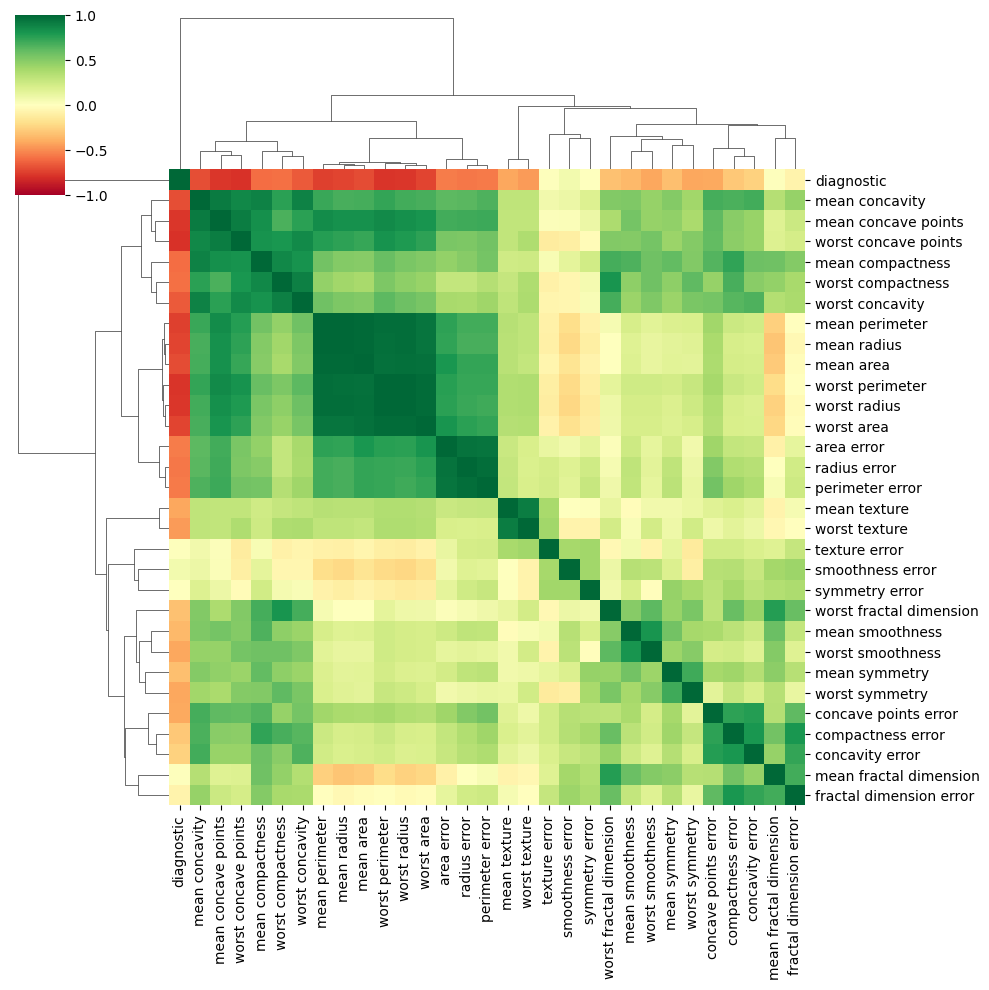

In [6]:
df_corr = df_cancer.corr()
df_corr

sns.clustermap( df_corr, cmap='RdYlGn', vmin=-1, vmax=1 )

### Correlaciones de datos categóricos

Para calcular la correlación entre variables categóricas, es necesario convertir estas variables a una representación numérica. Esto se puede hacer utilizando la técnica de codificación one-hot (también conocida como codificación de variables ficticias o dummy). La codificación one-hot convierte cada categoría en una variable binaria (1 si pertenece a la categoría, 0 si no) y luego calcula la correlación de Pearson entre estas variables binarias.

In [7]:
# Estos son datos de ejemplo
df_dummy = pd.DataFrame({
                         'sexo': ['M', 'F', 'M', 'F', 'M', 'M', 'F', 'F'],
                         'grupo_sanguineo': ['A', 'O', 'B', 'O', 'A', 'AB', 'B', 'O'],
                         'enfermedad': ['no', 'si', 'no', 'si', 'no', 'si', 'no', 'si']
                        })

# Convertir variables categóricas a variables binarias (one-hot encoding)
df_dummy_encoded = pd.get_dummies(df_dummy)
df_dummy_encoded

,sexo_F,sexo_M,grupo_sanguineo_A,grupo_sanguineo_AB,grupo_sanguineo_B,grupo_sanguineo_O,enfermedad_no,enfermedad_si
0,False,True,True,False,False,False,True,False
1,True,False,False,False,False,True,False,True
2,False,True,False,False,True,False,True,False
3,True,False,False,False,False,True,False,True
4,False,True,True,False,False,False,True,False
5,False,True,False,True,False,False,False,True
6,True,False,False,False,True,False,True,False
7,True,False,False,False,False,True,False,True


Ahora calculemos la correlación de estos datos codíficados. El resultado es una matriz de correlación que muestra la correlación entre todas las variables binarias.

<Axes: >

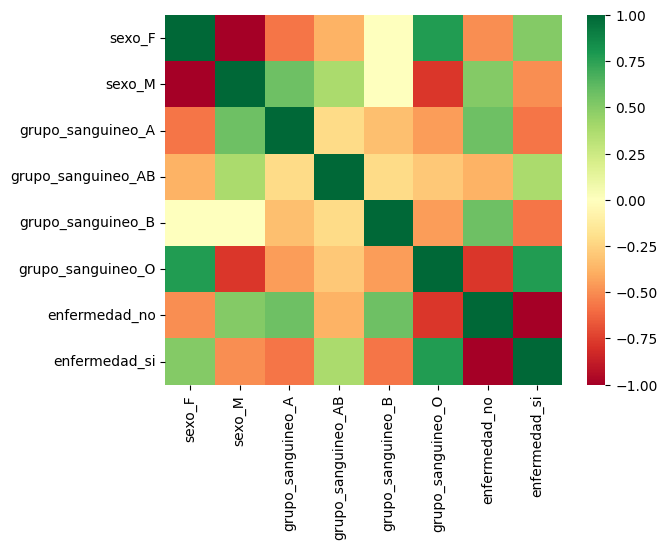

In [8]:
df_dummy_corr = df_dummy_encoded.corr()
df_dummy_corr
sns.heatmap( df_dummy_corr, cmap='RdYlGn', vmin=-1, vmax=1)

### Significancia estadística

El p-value o valor-p es una medida estadística que se utiliza para evaluar la significancia de una correlación o de cualquier otra prueba estadística. El p-value es la probabilidad de obtener un resultado al menos tan extremo como el que se observó, asumiendo que la hipótesis nula es verdadera. En otras palabras, el p-value nos indica qué tan probable es que la correlación observada se deba al azar o al azar y no a una verdadera relación entre las variables.

En el contexto de una correlación, si el p-value es menor que un nivel de significancia predeterminado (generalmente 0.05 o 0.01), se considera que la correlación es significativa y que la hipótesis nula (que no hay correlación) se debe rechazar. Por otro lado, si el p-value es mayor que el nivel de significancia, se considera que la correlación no es significativa y que no se puede rechazar la hipótesis nula.

Por ejemplo, para calcular la significancia estadística de una correlación es necesario usar la biblioteca `scipy` y la función `pearsonr`.


**Coeficiente de correlación de Pearson**

Suposiciones
* Linealidad
* Normalidad
* Escala de intervalo o razón
* Homocedasticidad: la variabilidad de una variable debe ser similar a lo largo de los valores de la otra.

Hipótesis
* Hipótesis nula ($H_0$): no hay correlación lineal entre las variables en la población
* Hipótesis alternativa ($H_1$): hay una correlación lineal significativa entre las variables

Criterio de aceptación/rechazo
* Se calcula un valor p asociado a la estadística de prueba.
* Se compara con un nivel de significancia (por ejemplo, 0.05)

In [9]:
#! pip install scipy
from scipy.stats import pearsonr

corr, p = pearsonr(df_cancer['mean perimeter'], df_cancer['mean fractal dimension'])
corr, p

(np.float64(-0.26147690806633345), np.float64(2.388802772935931e-10))

Entonces, asignemos a todas las correlaciones una significancia. Para hacer esto calcularemos los pares de correlaciones.



In [10]:
from itertools import combinations

cols = df_cancer.columns
df_corr = list()
for var1, var2 in combinations(cols, 2):
    data = df_cancer[[var1, var2]].dropna()
    corrp = pearsonr(data[var1],data[var2])
    df_corr.append( [var1, var2, data.shape[0], corrp.statistic, corrp.pvalue] )
df_corr = pd.DataFrame(df_corr)
df_corr.columns = ['var1','var2','N','pearson','p_pearson']
df_corr = df_corr.dropna().sort_values('pearson', ascending=False)
df_corr

,var1,var2,N,pearson,p_pearson
1,mean radius,mean perimeter,569,0.997855,0.000000e+00
411,worst radius,worst perimeter,569,0.993708,0.000000e+00
2,mean radius,mean area,569,0.987357,0.000000e+00
59,mean perimeter,mean area,569,0.986507,0.000000e+00
412,worst radius,worst area,569,0.984015,0.000000e+00
...,...,...,...,...,...
86,mean perimeter,diagnostic,569,-0.742636,8.436251e-101
419,worst radius,diagnostic,569,-0.776454,8.482292e-116
211,mean concave points,diagnostic,569,-0.776614,7.101150e-116
436,worst perimeter,diagnostic,569,-0.782914,5.771397e-119


Revisemos cuantas correlaciones no son significativas.

In [11]:
(df_corr['p_pearson']>0.05).sum()

np.int64(51)

Quedémonos solo con las correlaciones significativas

In [12]:
df_corr = df_corr[df_corr['p_pearson']<=0.05]

Es importante destacar que el que una correlación sea significativa estadísticamente no significa que sea fuerte. Por ejemplo, la mayor parte de las correlaciones se encuentran entre $-0.5$ y $0.5$, lo cual significa que son débiles. 

<Axes: ylabel='Frequency'>

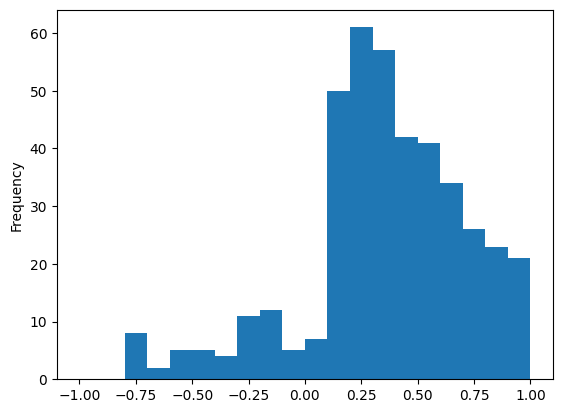

In [13]:
df_corr['pearson'].plot.hist(bins=[i/10 for i in range(-10,11,1)])

Muchas veces se fija un umbral mínimo para la correlación.

Grafiquemos las correlaciones lineales significativas y con valor absoluto mayor a 0.75.

<Axes: xlabel='var2', ylabel='var1'>

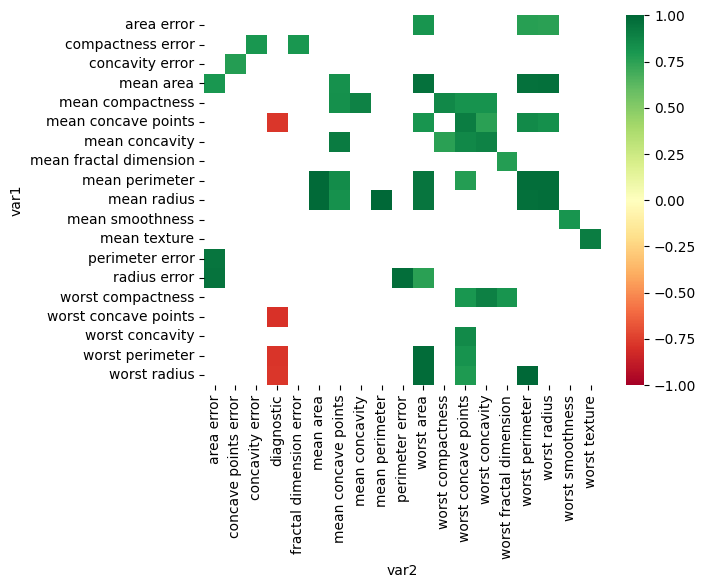

In [14]:
corr_thr = 0.75
data = df_corr[df_corr['pearson'].abs()>=corr_thr]
data = data.pivot(index='var1', columns='var2', values='pearson')
sns.heatmap( data, cmap='RdYlGn', vmin=-1, vmax=1)

## 11.c Pruebas de hipótesis múltiples

Las pruebas de hipótesis múltiples ocurren cuando se realizan varias pruebas estadísticas al mismo tiempo. 
El problema principal es que aumenta la probabilidad de obtener resultados falsos positivos (rechazar una hipótesis nula cuando en realidad es verdadera) simplemente por azar.


![Significancia estadistica](./images/xkcd_significant.png)

En nuestro caso hemos hecho 465 pruebas con p-value de 0.05, solo por azar 23 de nuestras correlaciones podrían suceder.

Para controlar este problema, se utilizan métodos de corrección, como:
* Bonferroni: divide el nivel de significancia entre el número de pruebas (α/nα/n).
* FDR (False Discovery Rate): como el método de Benjamini-Hochberg, que controla la proporción de falsos positivos entre los resultados significativos.

In [15]:
from statsmodels.stats.multitest import multipletests

rejected, pvals_corrected, _, _ = multipletests(df_corr['p_pearson'], alpha=0.05, method='bonferroni')

# Resultados
print("Hipótesis rechazadas:", rejected.sum())

Hipótesis rechazadas: 367


Revisemos las correlaciones que son significativas después del ajuste. Cómo pueden notar, se pierden muchas de las correlaciones.

In [16]:
df_corr['rejected'] = rejected
df_corr['p_corrected'] = pvals_corrected

df_corr[~df_corr['rejected']]

/tmp/ipykernel_11263/1925692448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['rejected'] = rejected
/tmp/ipykernel_11263/1925692448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['p_corrected'] = pvals_corrected


,var1,var2,N,pearson,p_pearson,rejected,p_corrected
91,mean area,mean symmetry,569,0.151293,0.000293,False,0.121103
295,perimeter error,smoothness error,569,0.151075,0.000299,False,0.123596
80,mean perimeter,worst smoothness,569,0.150549,0.000314,False,0.129817
7,mean radius,mean symmetry,569,0.147741,0.000406,False,0.168277
111,mean area,worst symmetry,569,0.143570,0.000593,False,0.245357
44,mean texture,concavity error,569,0.143293,0.000607,False,0.251486
384,concave points error,worst symmetry,569,0.143116,0.000617,False,0.255489
350,compactness error,worst texture,569,0.143003,0.000623,False,0.258071
268,radius error,worst smoothness,569,0.141919,0.000686,False,0.284081
435,worst perimeter,worst fractal dimension,569,0.138957,0.000889,False,0.368045


## 11.d PCA (Análisis de Componentes Principales)

El PCA es una técnica común para visualizar los datos con múltiples dimensiones, y es la base de la mayor parte de los algoritmos de reducción de la dimensionalidad.

### Escala de los datos

Muchos análisis son sensibles a diferencias en las escalas de los datos. Si las variables no se miden en una escala similar, debemos escalar las características antes de ejecutar PCA para nuestros datos.

`StandardScaler` es una clase en la biblioteca scikit-learn de Python que se utiliza para escalar los datos a una media cero y una desviación estándar de uno. Esto significa que la media de los datos se desplaza a cero y la escala se ajusta para que la varianza sea la misma en todas las características.

In [17]:
from sklearn.preprocessing import StandardScaler

standardized = StandardScaler()
scaled_data = standardized.fit_transform( df_cancer.drop('diagnostic', axis=1) )
scaled_data

df_scaled = pd.DataFrame(data=scaled_data, columns=cancer['feature_names'])
df_scaled['diagnostic'] = cancer['target']
df_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostic
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,0
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,0
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,0
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,0


El resultado de la transformación es que las características tienen una distribución normalizada con media de cero y desviación estandar de uno. Además, la normalización ayuda a evitar que características con varianza alta dominen la importancia de otras características con varianza baja.

In [18]:
df_scaled.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostic
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,...,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.627
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,...,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,0.484
min,-2.030,-2.229,-1.985,-1.454,-3.112,-1.610,-1.115,-1.262,-2.744,-1.820,...,-2.224,-1.693,-1.222,-2.683,-1.444,-1.306,-1.745,-2.161,-1.602,0.000
25%,-0.689,-0.726,-0.692,-0.667,-0.711,-0.747,-0.744,-0.738,-0.703,-0.723,...,-0.749,-0.690,-0.642,-0.691,-0.681,-0.757,-0.756,-0.642,-0.692,0.000
50%,-0.215,-0.105,-0.236,-0.295,-0.035,-0.222,-0.342,-0.398,-0.072,-0.178,...,-0.044,-0.286,-0.341,-0.047,-0.270,-0.218,-0.223,-0.127,-0.216,1.000
75%,0.469,0.584,0.500,0.364,0.636,0.494,0.526,0.647,0.531,0.471,...,0.658,0.540,0.358,0.598,0.540,0.531,0.713,0.450,0.451,1.000
max,3.971,4.652,3.976,5.251,4.771,4.568,4.244,3.928,4.485,4.911,...,3.886,4.287,5.930,3.955,5.113,4.701,2.686,6.046,6.847,1.000


Graficando

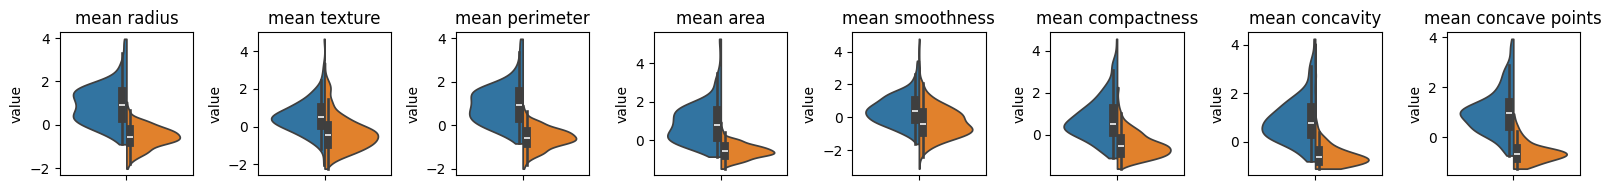

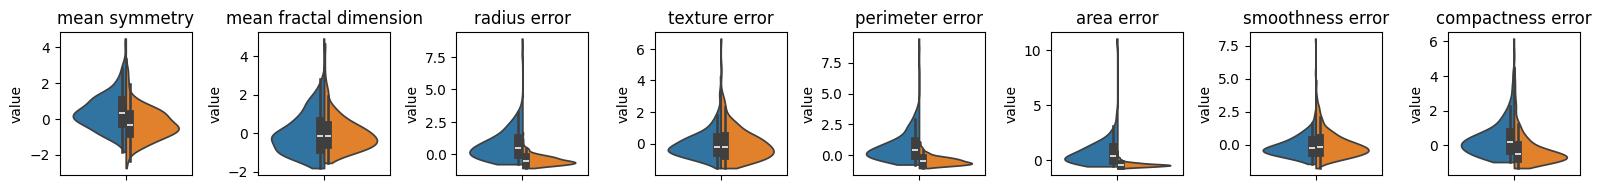

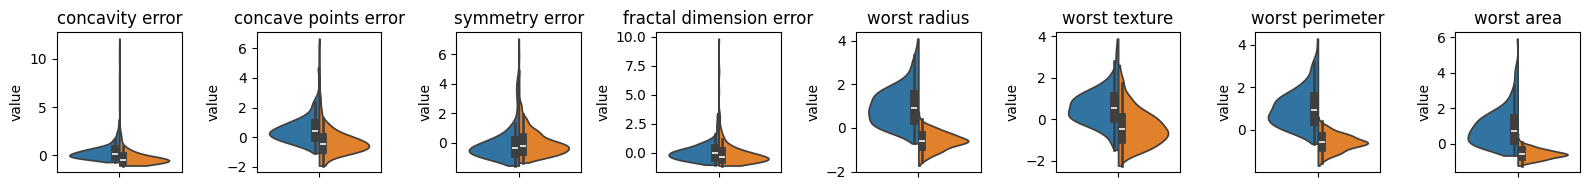

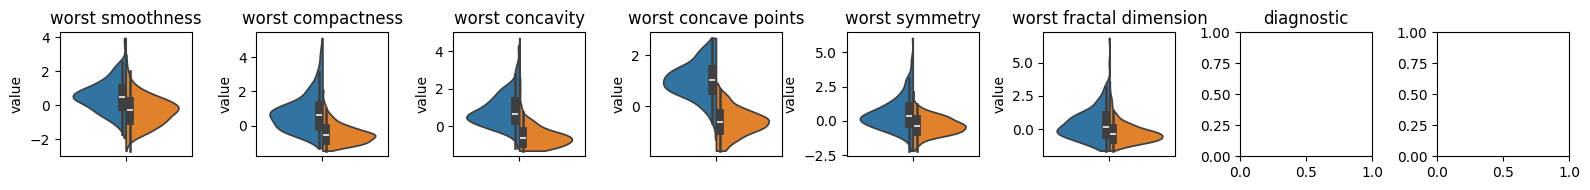

In [19]:
violin_plot_cancer(df_scaled)

### Obtención de componentes

PCA (Análisis de Componentes Principales) es una técnica estadística utilizada para reducir la dimensionalidad de un conjunto de datos. El PCA busca encontrar las combinaciones lineales de las variables originales que expliquen la mayor cantidad posible de la variabilidad en los datos. Estas nuevas variables, llamadas componentes principales, se ordenan en función de la cantidad de varianza que explican en los datos.

La idea detrás del PCA es que, en muchos casos, los datos pueden estar altamente correlacionados entre sí y pueden ser redundantes en términos de información. Al reducir la dimensionalidad de los datos mediante el PCA, podemos eliminar esta redundancia y conservar solo las variables más informativas y significativas para el análisis. 
El PCA se aplica a un conjunto de datos de alta dimensionalidad, se calculan los componentes principales, y se utilizan estos componentes para realizar análisis más simples, como clasificación, regresión o visualización.
El PCA es una técnica no supervisada, es decir, no requiere etiquetas o información de respuesta para llevar a cabo la reducción de dimensionalidad.

El análisis de PCA regresa un objeto que contiene bastante información, algunos de los cuales:
* components_: los vectores de carga (o dirección) de cada componente principal en términos de las características originales.
* explained_variance_: la varianza explicada por cada componente principal.
* explained_variance_ratio_: la proporción de la varianza explicada por cada componente principal

Los componentes se ordenan de acuerdo a la cantidad de varianza que explican. Se puede fijar cuantos componentes se quieren de regreso.

In [20]:
from sklearn.decomposition import PCA

n_components = 5
pca = PCA(n_components=n_components)
pca.fit(scaled_data)

df_components = pca.components_
df_components = pd.DataFrame(df_components, 
                             columns = df_scaled.drop('diagnostic', axis=1).columns,
                             index=['comp_{}'.format(i) for i in range(n_components)])

df_components.insert(0, 'explained_variance_percent', pca.explained_variance_ratio_ * 100)
df_components

,explained_variance_percent,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
comp_0,44.272026,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
comp_1,18.971182,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339
comp_2,9.393163,-0.008531,0.064550,-0.009314,0.028700,-0.104292,-0.074092,0.002734,-0.025564,-0.040240,...,-0.047507,-0.042298,-0.048547,-0.011902,-0.259798,-0.236076,-0.173057,-0.170344,-0.271313,-0.232791
comp_3,6.602135,-0.041409,0.603050,-0.041983,-0.053434,-0.159383,-0.031795,-0.019123,-0.065336,-0.067125,...,-0.015417,0.632808,-0.013803,-0.025895,-0.017652,0.091328,0.073951,-0.006007,0.036251,0.077053
comp_4,5.495768,-0.037786,0.049469,-0.037375,-0.010331,0.365089,-0.011704,-0.086375,0.043861,0.305941,...,0.004407,0.092883,-0.007454,0.027391,0.324435,-0.121804,-0.188519,-0.043332,0.244559,-0.094423


La contribución de cada variable original al componente se puede ver en la tabla de componentes. Si el valor es negativo significa que la correlación es negativa. De esta manera es posible ver cuáles variables contribuyeron principalmente a cada componente.

In [21]:
df_components.where( (df_components.abs() > 0.25) ).dropna(how='all', axis=1)

,explained_variance_percent,mean texture,mean smoothness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,smoothness error,compactness error,concavity error,symmetry error,fractal dimension error,worst texture,worst smoothness,worst concave points,worst symmetry,worst fractal dimension
comp_0,44.272026,NaN,NaN,0.2584,0.260854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.250886,NaN,NaN
comp_1,18.971182,NaN,NaN,NaN,NaN,NaN,0.366575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.280092,NaN,NaN,NaN,NaN,0.275339
comp_2,9.393163,NaN,NaN,NaN,NaN,NaN,NaN,0.268481,0.374634,0.266645,0.308839,NaN,NaN,0.288584,NaN,NaN,-0.259798,NaN,-0.271313,NaN
comp_3,6.602135,0.60305,NaN,NaN,NaN,NaN,NaN,NaN,0.359856,NaN,NaN,NaN,NaN,NaN,NaN,0.632808,NaN,NaN,NaN,NaN
comp_4,5.495768,NaN,0.365089,NaN,NaN,0.305941,NaN,NaN,NaN,NaN,NaN,-0.279968,-0.353982,0.252869,-0.263297,NaN,0.324435,NaN,NaN,NaN


### Visualización de datos

Para ver visualmente un PCA es necesario transformar los datos escalados para que roten y queden alineados con los ejes marcados por el PCA.

Una vez hecho esto se pueden graficar los datos usando un número de ejes que correspondan al número de componentes que se quieren ver.

/home/esther/anaconda3/envs/CursoPandas2025/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


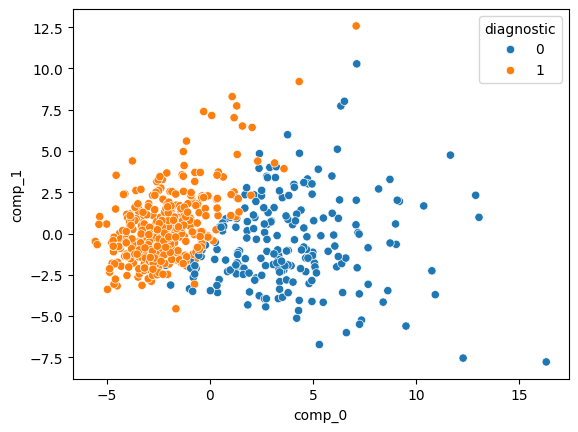

In [22]:
# transformar los datos y guardarlos en un df
df_data_pca = pca.transform(df_scaled.drop('diagnostic', axis=1))
df_data_pca = pd.DataFrame(df_data_pca, columns=['comp_{}'.format(i) for i in range(n_components)])
df_data_pca['diagnostic'] = df_scaled['diagnostic']
df_data_pca
# graficar
sns.scatterplot(data=df_data_pca, x='comp_0', y='comp_1', hue='diagnostic')
plt.show()

## 11.e Selección de variables

Los métodos de selección univariada utilizan pruebas estadísticas para seleccionar las características que tienen una relación más fuerte con la variable objetivo. Algunos ejemplos de pruebas estadísticas son ANOVA, chi-cuadrado y correlación de Pearson. En scikit-learn, la clase `SelectKBest` se utiliza para seleccionar las k mejores características según una prueba estadística dada. 
Es importante considerar el tipo y características de los datos al seleccionar la prueba estadística.

En este caso, las variables que nos interesan son las mediciones experimentales, mientras que la variable objetivo es si es benigno o maligno.


In [23]:
from sklearn.feature_selection import SelectKBest, chi2

feature_selection = SelectKBest(chi2, k=5)
feature_selection.fit(df_cancer.drop('diagnostic', axis=1), df_cancer['diagnostic'])
selected_features = list(cancer['feature_names'][feature_selection.get_support()])
selected_features

[np.str_('mean perimeter'),
 np.str_('mean area'),
 np.str_('area error'),
 np.str_('worst perimeter'),
 np.str_('worst area')]

A continuación grafiquemos las variables. En general se nota cómo se agrupan los datos en dos grupos separados, pero noten cómo hay un sobrelape entre grupos.

In [ ]:
df_selected = df_cancer[ selected_features + ['diagnostic'] ]
sns.pairplot(df_selected, hue='diagnostic')

## 11.f Regresión logística

La regresión logística es una técnica de modelado estadístico que se utiliza para predecir la probabilidad de que ocurra un evento binario (sí o no, verdadero o falso) en función de una o más variables independientes. A diferencia de la regresión lineal, que se utiliza para predecir valores numéricos continuos, la regresión logística se utiliza para predecir una variable categórica.
En Python, se puede realizar una regresión logística utilizando la biblioteca Scikit-Learn. 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Un modelo es una representación matemática de la realidad. Al usar un modelo logístico ya estamos haciendo suposiciones sobre como se comporta el fenómeno. 
Para evaluar que tan bien describe nuestro modelo la realidad dividiremos los datos en dos conjuntos: entrenamiento (`train`) y examen (`test`). El conjunto de `train` se usa para ajustar el modelo y el de `test` se usa para evaluar que tan bien ajustado quedo el modelo. En algunos casos se utiliza un tercer grupo para evaluar el sobreajuste.

Dentro de cada conjunto separaremos en una matriz de variables `X`, la cual suponemos explican si una medición `Y` es benigna o maligna.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3, random_state=42)
X_train, y_train

A partir de esto declaramos el modelo y lo ajustamos con las datos de train.

In [ ]:
modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_train, y_train)

Ahora, el modelo fue entrenado con los datos de train. Podemos usar los datos de test que nunca ha visto para generar una predicción de si las mediciones en test pertenecen a una u otra clasificación.

In [ ]:
# Realizar predicciones sobre los datos de prueba
y_pred = modelo.predict(X_test)
y_pred

Para evaluar que tan bueno es el modelo compararemos la predicción con los datos experimentales que separamos de test.

In [ ]:
# Calcular la precisión del modelo
precision = accuracy_score(y_test, y_pred)
precision


### Curva de ROC

Para evaluar que tan bueno es un modelo se necesitan entender ciertos conceptos:

**Error Tipo I (Falso Positivo)**
Es cuando el modelo predice positivamente un caso que en realidad es negativo.
* Una muestra es interpretada por el modelo como positiva para cáncer, pero no hay malignidad. Esto tiene como consecuencia ansiedad innecesaria, realización de cirugías innecesarias y sobrecarga del sistema de salud.

**2. Error Tipo II (Falso Negativo)**
Es cuando el modelo predice negativamente un caso que en realidad es positivo.
* La muestra es interpretada como benigna por el modelo, pero la paciente realmente tiene un tumor maligno. Esto tiene como consecuencia retrasos en el diagnóstico y tratamiento, con potencial impacto negativo en la supervivencia.


![Significancia estadistica](images/error_tipoIyII.jpg)

A partir de esto podemos definir varias métricas

- **VP:** Verdaderos positivos
- **FN:** Falsos negativos
- **VN:** Verdaderos negativos


**Sensibilidad** (Recall o Verdaderos Positivos / Tasa de Detección). 
Mide la capacidad del modelo para identificar correctamente los casos positivos.
Por ejemplo, si 100 mujeres tienen cáncer y el modelo detecta correctamente 90 de ellas, la sensibilidad es 90%.
$$\text{Sensibilidad} = \frac{VP}{VP + FN}$$

**Especificidad** (Tasa de Verdaderos Negativos).
Mide la capacidad del modelo para identificar correctamente los casos negativos.
Por ejemplo, si 900 mujeres no tienen cáncer y el modelo clasifica correctamente a 855 como sanas, la especificidad es 95%.
$$\text{Especificidad} = \frac{VN}{VN + FP}$$

**Precisión** (Precision o Valor Predictivo Positivo).
Mide la proporción de predicciones positivas que fueron correctas.
Por ejemplo, si el modelo predice cáncer en 120 mujeres, pero solo 90 realmente lo tienen, la precisión es 75%.
$$\text{Precisión} = \frac{VP}{VP + FP}$$


La **curva ROC** (Receiver Operating Characteristic) es una herramienta gráfica utilizada para evaluar el desempeño de un modelo de clasificación binaria, mostrando la relación entre `sensibilidad` y `1 - especificidad` a diferentes umbrales de decisión.

Cómo se construye:
* El modelo produce probabilidades (`.predict_proba()`).
* Se varía el umbral de decisión y se calculan TPR y FPR.
* Se grafican los puntos (FPR, TPR)

Si la curva está cerca de la esquina superior izquierda (0,1) el modelo tiene alta sensibilidad y baja tasa de falsos positivos, es decir, tiene un buen desempeño. Si la curva está cerca de la diagonal (línea 45°) el modelo no tiene capacidad de discriminación, es decir, predice al azar.

La métrica usada es el **Área Bajo la Curva** (AUC, Area Under Curve)
* $AUC = 1.0$: clasificación perfecta.
* $AUC = 0.5$: sin capacidad discriminativa (azar).
* $AUC < 0.5$: peor que el azar (modelo invertido).


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_probs = modelo.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel('Falso positivo')
plt.ylabel('Verdadero positivo')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## 11.g Resumen

En esta lección hemos aprendido varios algoritmos
* Correlación de Pearson `scipy.stats.pearsonr`
* PCA (análisis de componentes principales) `sklearn.decomposition.PCA`
* Selección de variables `sklearn.feature_selection.SelectKBest`
* Regresión logística `sklearn.linear_model.LogisticRegression`

Además, aprendimos varios conceptos cómo:
* Pruebas de hipótesis múltiple `statsmodels.stats.multitest.multipletests`
* Preprocesamiento de datos `sklearn.preprocessing.StandardScaler`
* Aprendizaje supervisado y conjuntos de entrenamiento `train` y prueba `test`
* Error tipo I (falso positivo) y error tipo II (falso negativo)
* Sensibilidad, especificidad y precisión

Estos son temas que se ven comúnmente en un curso de ciencia de datos, este notebook es solo una muestra general.

![Significancia estadistica](images/Dunning-Kruger.jpg)

**¡Gracias!**